# Parental Education and Educational Attainment Among 18–25-Year-Olds in Denmark

# Problem Formulation (Stage 1)


# Context
Education is one of the strongest indicators of future labour market opportunities, income potential, and social mobility. For young adults, educational pathways are often influenced by both age and family background. One important background factor is the parents’ highest completed education, which may reflect access to resources, expectations, and support during a young person’s education journey.

This project uses data from Statistics Denmark to explore how the completed education of 18–25-year-olds differs across age groups and parental education groups from 2020 to 2024.



# Problem Statement
This project investigates whether the educational attainment of young people aged 18–25 in Denmark is associated with their age and with their parents’ highest completed education. The purpose is to identify patterns in how educational outcomes differ across family background groups and to prepare a structured dataset that can later be used for predictive analytics and BI visualisation.



# Research Questions
**RQ1**
- Does parents’ highest completed education appear to influence the educational attainment of 18–25-year-olds in Denmark?

**RQ2**
- How does educational attainment change across age groups from 18 to 25 years?

**RQ3**
- Can educational attainment category be predicted from variables such as age and parents’ education in a later machine learning stage?



# Hypotheses
**H1**
- There is a significant association between parents’ highest completed education and the educational attainment of 18–25-year-olds.

**H2**
- Older age groups are more likely to have completed higher educational categories than younger age groups.

**H3**
- Age and parents’ education contain enough information to support predictive modelling of educational attainment.



# Dataset
The dataset comes from Statistics Denmark and is based on the table **STATUSU2**. It contains aggregated counts for 18–25-year-olds by:
- educational status / completed education category
- age
- parents’ highest completed education
- year (2020–2024)

The source is a hierarchical export, so the raw structure must be transformed into a clean tabular format before analysis.



# BI relevance
The project is relevant for Business Intelligence because it transforms official statistical data into a format that can support:
- pattern discovery across demographic and background groups
- evidence-based discussion about educational inequality
- future dashboards and reporting
- later predictive modelling and decision support



# Project Plan
- Stage 1 – problem formulation
- Stage 2 – data preparation and exploratory data analysis
- Stage 3 – predictive modelling
- Stage 4 – deployment and visual communication


# Libraries

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, spearmanr

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


In [2]:
# for ML methods and algorithms
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.linear_model import LinearRegression
from sklearn import metrics
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer

# for stadardization
from sklearn.preprocessing import StandardScaler

# for cluster
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
from sklearn.preprocessing import LabelEncoder

# Data Preparation and Exploration (Stage 2)

## Step 1 — Load the raw dataset

In [4]:

raw = pd.read_excel('data\exam-data-2.xlsx', header=None)
raw.head(12)


,0,1,2,3,4,5,6,7,8
0,"18-25 årige efter uddannelsesstatus, uddannels...",NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Enhed: Antal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,2020.0,2021.0,2022.0,2023.0,2024.0
3,Fuldført uddannelse,Ingen ungdomsuddannelse,18 år,H10 Grundskole,0.0,0.0,0.0,0.0,0.0
4,NaN,NaN,NaN,H20 Gymnasiale uddannelser,0.0,0.0,0.0,0.0,0.0
5,NaN,NaN,NaN,H30 Erhvervsfaglige uddannelser,0.0,0.0,0.0,0.0,0.0
6,NaN,NaN,NaN,H35 Adgangsgivende uddannelsesforløb,0.0,0.0,0.0,0.0,0.0
7,NaN,NaN,NaN,"H40 Korte videregående uddannelser, KVU",0.0,0.0,0.0,0.0,0.0
8,NaN,NaN,NaN,"H50 Mellemlange videregående uddannelser, MVU",0.0,0.0,0.0,0.0,0.0
9,NaN,NaN,NaN,"H60 Bacheloruddannelser, BACH",0.0,0.0,0.0,0.0,0.0



The raw file contains metadata rows and a hierarchical structure where some category values are only written once and then omitted in the following rows. This means the dataset is not immediately ready for BI analysis.


## Step 2 — Clean and structure the dataset

In [5]:

# remove metadata rows and assign column names

df = raw.iloc[3:].copy().reset_index(drop=True)
df.columns = [
    'status',
    'education',
    'age',
    'parent_education',
    '2020',
    '2021',
    '2022',
    '2023',
    '2024'
]

# forward fill hierarchical labels
for col in ['status', 'education', 'age']:
    df[col] = df[col].replace(' ', pd.NA).ffill()

# numeric conversion
for year in ['2020', '2021', '2022', '2023', '2024']:
    df[year] = pd.to_numeric(df[year], errors='coerce')

# helper features

df['age_num'] = df['age'].str.extract(r'(\d+)').astype(int)
df['total_2020_2024'] = df[['2020', '2021', '2022', '2023', '2024']].sum(axis=1)

def parent_level(x):
    if x == 'H10 Grundskole':
        return 'Basic school'
    elif x in ['H20 Gymnasiale uddannelser', 'H30 Erhvervsfaglige uddannelser', 'H35 Adgangsgivende uddannelsesforløb']:
        return 'Upper secondary / vocational'
    elif x in [
        'H40 Korte videregående uddannelser, KVU',
        'H50 Mellemlange videregående uddannelser, MVU',
        'H60 Bacheloruddannelser, BACH',
        'H70 Lange videregående uddannelser, LVU',
        'H80 Ph.d. og forskeruddannelser'
    ]:
        return 'Higher education'
    else:
        return 'Unknown / not stated'


def education_level(x):
    if x == 'H20 Gymnasiale uddannelser':
        return 'Upper secondary'
    elif x == 'H29 Erhvervsfaglige grundforløb':
        return 'Vocational basic'
    elif x == 'H30 Erhvervsfaglige uddannelser':
        return 'Vocational completed'
    else:
        return 'Higher education'


def education_score(x):
    mapping = {
        'H29 Erhvervsfaglige grundforløb': 1,
        'H20 Gymnasiale uddannelser': 2,
        'H30 Erhvervsfaglige uddannelser': 3,
        'Andre højere uddannelser': 4
    }
    return mapping.get(x, np.nan)


df['parent_level'] = df['parent_education'].apply(parent_level)
df['education_level'] = df['education'].apply(education_level)
df['education_score'] = df['education'].apply(education_score)

# drop constant status column after inspection
if df['status'].nunique() == 1:
    df = df.drop(columns='status')

# optional export of cleaned version
# df.to_csv('statusu2_clean.csv', index=False)

df.head(10)


,education,age,parent_education,2020,2021,2022,2023,2024,age_num,total_2020_2024,parent_level,education_level,education_score
0,Ingen ungdomsuddannelse,18 år,H10 Grundskole,0.0,0.0,0.0,0.0,0.0,18,0.0,Basic school,Higher education,NaN
1,Ingen ungdomsuddannelse,18 år,H20 Gymnasiale uddannelser,0.0,0.0,0.0,0.0,0.0,18,0.0,Upper secondary / vocational,Higher education,NaN
2,Ingen ungdomsuddannelse,18 år,H30 Erhvervsfaglige uddannelser,0.0,0.0,0.0,0.0,0.0,18,0.0,Upper secondary / vocational,Higher education,NaN
3,Ingen ungdomsuddannelse,18 år,H35 Adgangsgivende uddannelsesforløb,0.0,0.0,0.0,0.0,0.0,18,0.0,Upper secondary / vocational,Higher education,NaN
4,Ingen ungdomsuddannelse,18 år,"H40 Korte videregående uddannelser, KVU",0.0,0.0,0.0,0.0,0.0,18,0.0,Higher education,Higher education,NaN
5,Ingen ungdomsuddannelse,18 år,"H50 Mellemlange videregående uddannelser, MVU",0.0,0.0,0.0,0.0,0.0,18,0.0,Higher education,Higher education,NaN
6,Ingen ungdomsuddannelse,18 år,"H60 Bacheloruddannelser, BACH",0.0,0.0,0.0,0.0,0.0,18,0.0,Higher education,Higher education,NaN
7,Ingen ungdomsuddannelse,18 år,"H70 Lange videregående uddannelser, LVU",0.0,0.0,0.0,0.0,0.0,18,0.0,Higher education,Higher education,NaN
8,Ingen ungdomsuddannelse,18 år,H80 Ph.d. og forskeruddannelser,0.0,0.0,0.0,0.0,0.0,18,0.0,Higher education,Higher education,NaN
9,Ingen ungdomsuddannelse,18 år,H90 Uoplyst mv.,0.0,0.0,0.0,0.0,0.0,18,0.0,Unknown / not stated,Higher education,NaN



The data is now transformed into a structured table with one row per combination of:
- youth education category
- age
- parents’ highest education
- yearly counts from 2020 to 2024

This makes it suitable for descriptive statistics, visualisation, and later machine learning.


## Step 3 — Inspect the cleaned dataset

In [6]:
df.shape

(400, 13)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   education         400 non-null    str    
 1   age               400 non-null    str    
 2   parent_education  400 non-null    str    
 3   2020              400 non-null    float64
 4   2021              400 non-null    float64
 5   2022              400 non-null    float64
 6   2023              400 non-null    float64
 7   2024              400 non-null    float64
 8   age_num           400 non-null    int64  
 9   total_2020_2024   400 non-null    float64
 10  parent_level      400 non-null    str    
 11  education_level   400 non-null    str    
 12  education_score   320 non-null    float64
dtypes: float64(7), int64(1), str(5)
memory usage: 80.1 KB


In [8]:
df.head()

,education,age,parent_education,2020,2021,2022,2023,2024,age_num,total_2020_2024,parent_level,education_level,education_score
0,Ingen ungdomsuddannelse,18 år,H10 Grundskole,0.0,0.0,0.0,0.0,0.0,18,0.0,Basic school,Higher education,NaN
1,Ingen ungdomsuddannelse,18 år,H20 Gymnasiale uddannelser,0.0,0.0,0.0,0.0,0.0,18,0.0,Upper secondary / vocational,Higher education,NaN
2,Ingen ungdomsuddannelse,18 år,H30 Erhvervsfaglige uddannelser,0.0,0.0,0.0,0.0,0.0,18,0.0,Upper secondary / vocational,Higher education,NaN
3,Ingen ungdomsuddannelse,18 år,H35 Adgangsgivende uddannelsesforløb,0.0,0.0,0.0,0.0,0.0,18,0.0,Upper secondary / vocational,Higher education,NaN
4,Ingen ungdomsuddannelse,18 år,"H40 Korte videregående uddannelser, KVU",0.0,0.0,0.0,0.0,0.0,18,0.0,Higher education,Higher education,NaN



### Data relevance
The dataset is relevant because it directly contains the variables needed to answer the research questions: youth education category, age, parental education, and time.


### Check for missing values and duplicates

In [9]:
print(df.isna().sum())
print('\nDuplicates:', df.duplicated().sum())

education            0
age                  0
parent_education     0
2020                 0
2021                 0
2022                 0
2023                 0
2024                 0
age_num              0
total_2020_2024      0
parent_level         0
education_level      0
education_score     80
dtype: int64

Duplicates: 0



### Data quality assessment
- **Relevant:** the variables match the problem formulation.
- **Sufficient:** the dataset covers 320 observations across 8 ages, 10 parental education groups, 4 youth education categories, and 5 years.
- **Structured:** the hierarchical source has been converted to a flat table.
- **Complete:** no missing values were found after cleaning.
- **Properly scaled:** age has been converted to a numeric variable (`age_num`) and aggregate totals were created for easier comparison.


## Step 4 — Basic category overview

In [10]:
print('Youth education categories:')
print(df['education'].unique())

print('\nParent education categories:')
print(df['parent_education'].unique())

print('\nAge groups:')
print(df['age'].unique())

Youth education categories:
<ArrowStringArray>
[        'Ingen ungdomsuddannelse',      'H20 Gymnasiale uddannelser',
 'H29 Erhvervsfaglige grundforløb', 'H30 Erhvervsfaglige uddannelser',
        'Andre højere uddannelser']
Length: 5, dtype: str

Parent education categories:
<ArrowStringArray>
[                               'H10 Grundskole',
                    'H20 Gymnasiale uddannelser',
               'H30 Erhvervsfaglige uddannelser',
          'H35 Adgangsgivende uddannelsesforløb',
       'H40 Korte videregående uddannelser, KVU',
 'H50 Mellemlange videregående uddannelser, MVU',
                 'H60 Bacheloruddannelser, BACH',
       'H70 Lange videregående uddannelser, LVU',
               'H80 Ph.d. og forskeruddannelser',
                               'H90 Uoplyst mv.']
Length: 10, dtype: str

Age groups:
<ArrowStringArray>
['18 år', '19 år', '20 år', '21 år', '22 år', '23 år', '24 år', '25 år']
Length: 8, dtype: str


## Step 5 — Descriptive statistics

In [11]:
df[['2020','2021','2022','2023','2024','total_2020_2024']].describe()

,2020,2021,2022,2023,2024,total_2020_2024
count,400.000000,400.000000,400.000000,400.000000,400.000000,400.00000
mean,986.702500,988.060000,1004.262500,1006.767500,1011.087500,4996.88000
std,2693.711869,2663.579869,2658.456103,2634.565723,2626.023555,13253.62022
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5.000000,5.000000,6.000000,7.000000,6.000000,27.50000
75%,407.250000,450.750000,477.750000,479.750000,508.500000,2265.25000
max,15839.000000,15490.000000,15131.000000,14366.000000,14059.000000,73697.00000


In [12]:

education_totals = df.groupby('education')[['2020','2021','2022','2023','2024']].sum()
parent_totals = df.groupby('parent_education')[['2020','2021','2022','2023','2024']].sum()
age_totals = df.groupby('age')[['2020','2021','2022','2023','2024']].sum()

education_totals


,2020,2021,2022,2023,2024
education,,,,,
Andre højere uddannelser,20275.0,20439.0,23639.0,25761.0,29146.0
H20 Gymnasiale uddannelser,311326.0,313211.0,316976.0,316678.0,315281.0
H29 Erhvervsfaglige grundforløb,0.0,0.0,0.0,0.0,0.0
H30 Erhvervsfaglige uddannelser,63080.0,61574.0,61090.0,60268.0,60008.0
Ingen ungdomsuddannelse,0.0,0.0,0.0,0.0,0.0


In [13]:
parent_totals

,2020,2021,2022,2023,2024
parent_education,,,,,
H10 Grundskole,21778.0,21159.0,20548.0,19763.0,19059.0
H20 Gymnasiale uddannelser,9949.0,10107.0,10031.0,9938.0,9722.0
H30 Erhvervsfaglige uddannelser,136806.0,132493.0,128546.0,123591.0,118878.0
H35 Adgangsgivende uddannelsesforløb,269.0,264.0,287.0,283.0,268.0
"H40 Korte videregående uddannelser, KVU",26554.0,26784.0,27089.0,27260.0,27434.0
"H50 Mellemlange videregående uddannelser, MVU",92039.0,92372.0,93557.0,94357.0,95276.0
"H60 Bacheloruddannelser, BACH",6185.0,6464.0,6740.0,7051.0,7382.0
"H70 Lange videregående uddannelser, LVU",53052.0,55132.0,57917.0,60793.0,63550.0
H80 Ph.d. og forskeruddannelser,6962.0,7416.0,7901.0,8525.0,9089.0


In [14]:
age_totals

,2020,2021,2022,2023,2024
age,,,,,
18 år,5459.0,5924.0,6555.0,6713.0,6538.0
19 år,30938.0,31212.0,31099.0,31508.0,30633.0
20 år,49215.0,50337.0,51125.0,51452.0,52072.0
21 år,54965.0,55584.0,57288.0,56991.0,57151.0
22 år,58504.0,59421.0,60423.0,61062.0,60938.0
23 år,63106.0,61636.0,62984.0,63513.0,64068.0
24 år,64075.0,65452.0,64446.0,65183.0,65983.0
25 år,68419.0,65658.0,67785.0,66285.0,67052.0



The descriptive statistics make it possible to compare the size of education categories across years and to see how the counts vary between age groups and parental education groups.


## Step 6 — Visual exploration

### 6.1 Total completed education by category over time

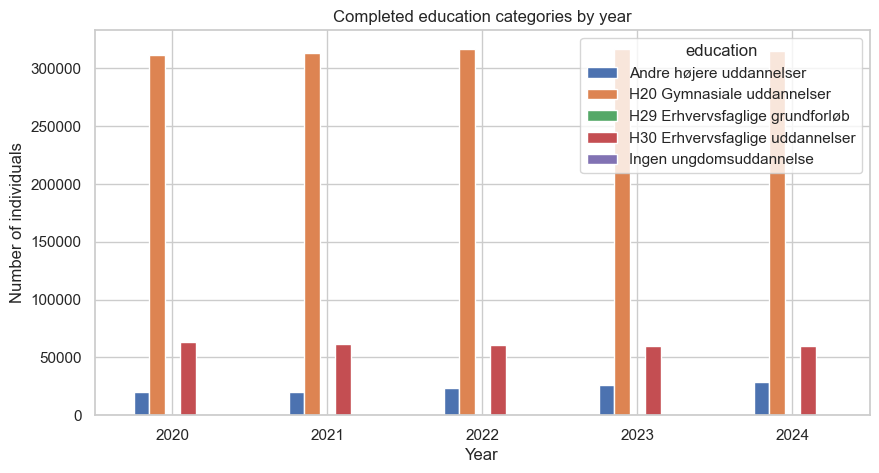

In [15]:

education_totals.T.plot(kind='bar', figsize=(10,5))
plt.title('Completed education categories by year')
plt.xlabel('Year')
plt.ylabel('Number of individuals')
plt.xticks(rotation=0)
plt.show()



The plot shows that gymnasiale uddannelser and erhvervsfaglige uddannelser dominate the dataset, while the category “Andre højere uddannelser” is much smaller. The vocational basic category is effectively zero in this completed-education dataset.


### 6.2 Education distribution by age in 2024

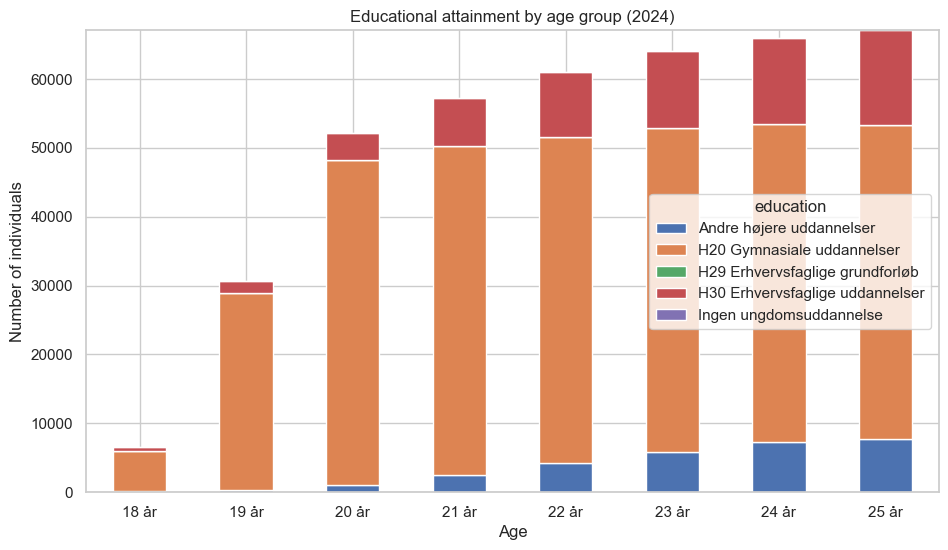

In [16]:

age_2024 = df.pivot_table(index='age', columns='education', values='2024', aggfunc='sum', fill_value=0)
age_2024.plot(kind='bar', stacked=True, figsize=(11,6))
plt.title('Educational attainment by age group (2024)')
plt.xlabel('Age')
plt.ylabel('Number of individuals')
plt.xticks(rotation=0)
plt.show()



The stacked bar chart suggests that the composition changes with age. Higher education becomes more visible in the older age groups, which is expected because more people have had time to finish longer study paths.


### 6.3 Education distribution by parents’ education in 2024

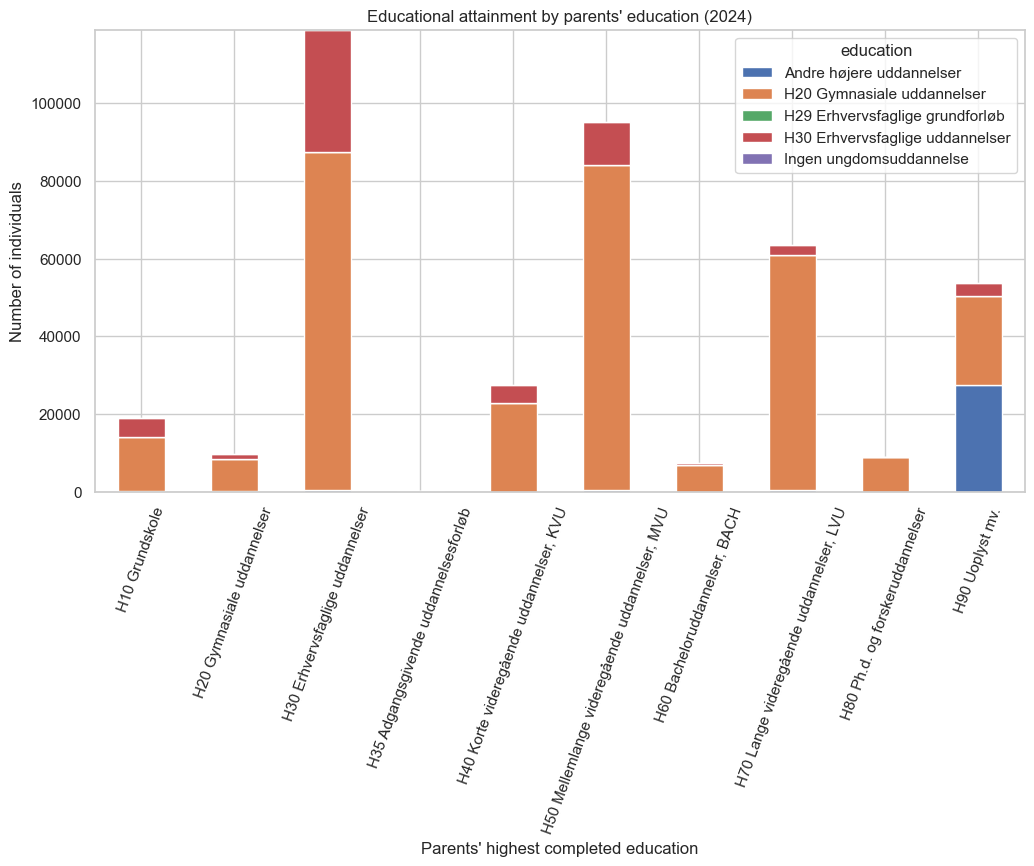

In [17]:

parent_2024 = df.pivot_table(index='parent_education', columns='education', values='2024', aggfunc='sum', fill_value=0)
parent_2024.plot(kind='bar', stacked=True, figsize=(12,6))
plt.title("Educational attainment by parents' education (2024)")
plt.xlabel("Parents' highest completed education")
plt.ylabel('Number of individuals')
plt.xticks(rotation=70)
plt.show()



There are visible differences across parental education groups. Some groups are heavily concentrated in gymnasiale or vocational outcomes, while others show a relatively larger share of higher education.


### 6.4 Share of higher education by age in 2024

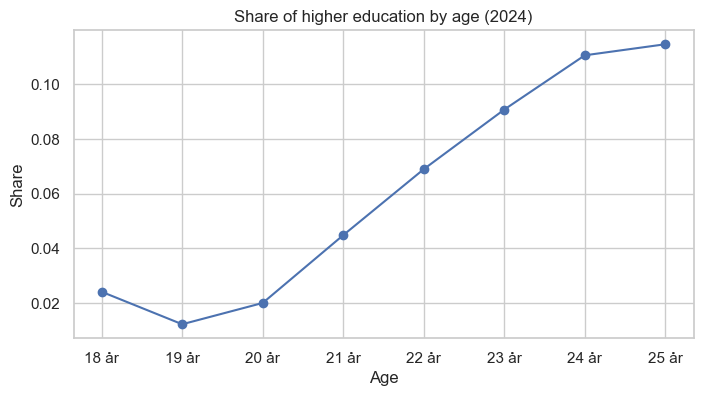

In [18]:

age_share_2024 = age_2024.div(age_2024.sum(axis=1), axis=0)

age_share_2024['Andre højere uddannelser'].plot(marker='o', figsize=(8,4))
plt.title('Share of higher education by age (2024)')
plt.xlabel('Age')
plt.ylabel('Share')
plt.xticks(rotation=0)
plt.show()



The share of higher education rises with age, which supports the expectation that older young adults have had more time to complete more advanced education.


## Step 7 — Distribution and outlier inspection

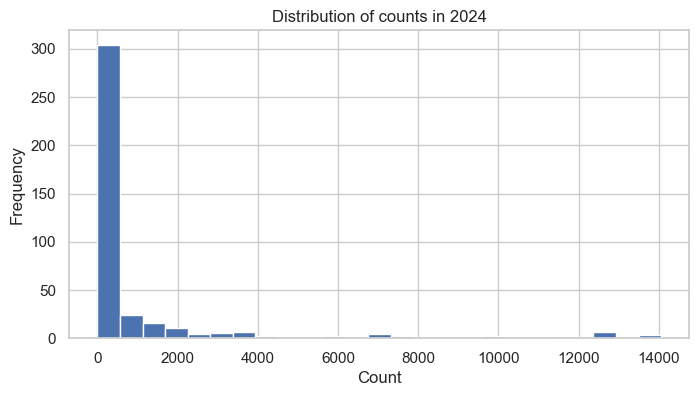

In [19]:
plt.figure(figsize=(8,4))
plt.hist(df['2024'], bins=25)
plt.title('Distribution of counts in 2024')
plt.xlabel('Count')
plt.ylabel('Frequency')
plt.show()

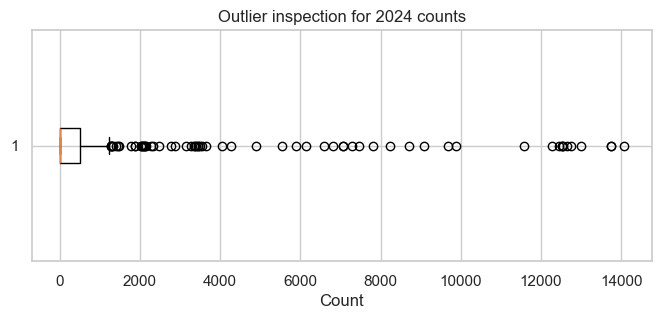

In [20]:
plt.figure(figsize=(8,3))
plt.boxplot(df['2024'], vert=False)
plt.title('Outlier inspection for 2024 counts')
plt.xlabel('Count')
plt.show()


The distribution is strongly right-skewed. A few combinations contain very large counts, but these reflect real population patterns in aggregated official statistics rather than obvious data errors. Therefore, the values are kept.


## Step 8 — Inferential statistics

### 8.1 Chi-square test: parents’ education vs youth education

In [21]:

parent_table = df.pivot_table(
    index='parent_education',
    columns='education',
    values='total_2020_2024',
    aggfunc='sum',
    fill_value=0
)

# remove columns with only zeros
parent_table = parent_table.loc[:, parent_table.sum(axis=0) > 0]

chi2_parent, p_parent, dof_parent, expected_parent = chi2_contingency(parent_table)

print('Chi-square statistic:', chi2_parent)
print('P-value:', p_parent)
print('Degrees of freedom:', dof_parent)


Chi-square statistic: 903584.7920426569
P-value: 0.0
Degrees of freedom: 18



A chi-square test is appropriate here because both main variables are categorical and the dataset contains aggregated counts.

The p-value is effectively 0, which indicates a statistically significant association between parents’ education and the educational attainment category of 18–25-year-olds. This supports **H1**.


In [22]:
parent_table = df.pivot_table(
    index='parent_education',
    columns='education',
    values='total_2020_2024',
    aggfunc='sum',
    fill_value=0
)

parent_table = parent_table.loc[:, parent_table.sum(axis=0) > 0]

This heatmap shows the distribution of youth educational attainment across different parental education groups. Each cell represents the number of individuals with a specific combination of parents' education and youth education. Darker colors indicate larger population counts. The visualization suggests that educational outcomes vary across parental education groups, which is confirmed by the chi-square test indicating a statistically significant association.

Since the heatmap shows population counts, larger parental education groups naturally appear darker. Therefore, the chi-square test was used to statistically evaluate the relationship.

In [23]:
parent_share = parent_table.div(parent_table.sum(axis=1), axis=0)

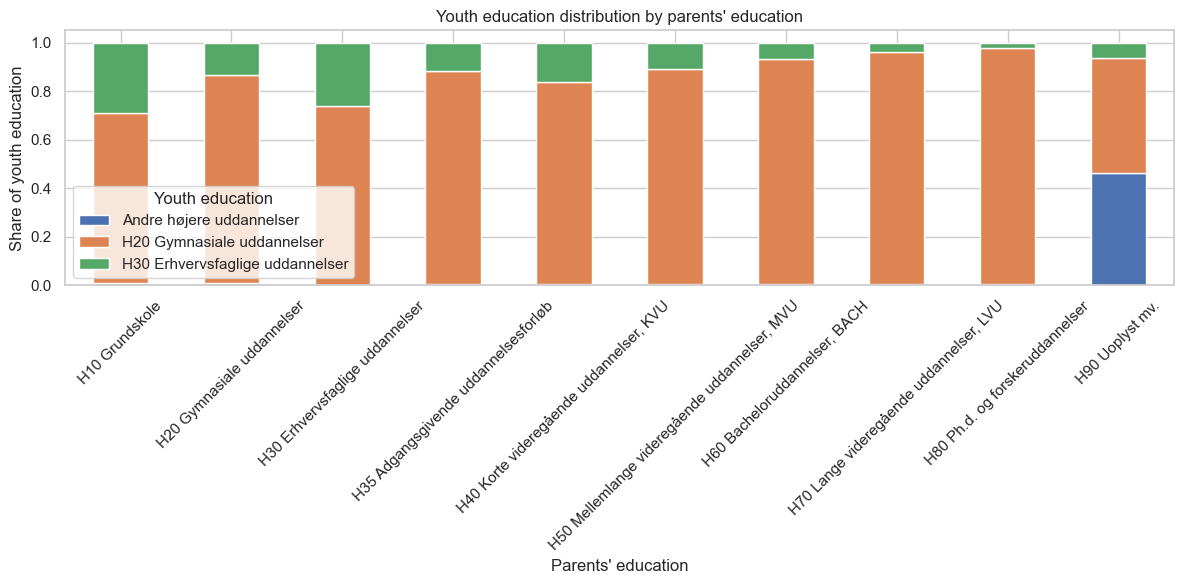

In [24]:
import matplotlib.pyplot as plt

parent_share.plot(
    kind="bar",
    stacked=True,
    figsize=(12,6)
)

plt.title("Youth education distribution by parents' education")
plt.xlabel("Parents' education")
plt.ylabel("Share of youth education")
plt.xticks(rotation=45)
plt.legend(title="Youth education")

plt.tight_layout()
plt.show()

In [25]:
# Beregn procentfordeling per række (forældrenes uddannelsesniveau)
parent_pct = parent_table.div(parent_table.sum(axis=1), axis=0) * 100

# Rund af for overblik
print(parent_pct.round(2))

education                                      Andre højere uddannelser  \
parent_education                                                          
H10 Grundskole                                                     0.85   
H20 Gymnasiale uddannelser                                         1.18   
H30 Erhvervsfaglige uddannelser                                    0.37   
H35 Adgangsgivende uddannelsesforløb                               0.66   
H40 Korte videregående uddannelser, KVU                            0.42   
H50 Mellemlange videregående uddannelser, MVU                      0.43   
H60 Bacheloruddannelser, BACH                                      0.63   
H70 Lange videregående uddannelser, LVU                            0.62   
H80 Ph.d. og forskeruddannelser                                    0.66   
H90 Uoplyst mv.                                                   46.42   

education                                      H20 Gymnasiale uddannelser  \
parent_education      

### 8.2 Chi-square test: age vs youth education

In [26]:

age_table = df.pivot_table(
    index='age',
    columns='education',
    values='total_2020_2024',
    aggfunc='sum',
    fill_value=0
)

age_table = age_table.loc[:, age_table.sum(axis=0) > 0]

chi2_age, p_age, dof_age, expected_age = chi2_contingency(age_table)

print('Chi-square statistic:', chi2_age)
print('P-value:', p_age)
print('Degrees of freedom:', dof_age)


Chi-square statistic: 95524.9117679783
P-value: 0.0
Degrees of freedom: 14



The result shows a statistically significant association between age and education category. In other words, educational attainment is not distributed equally across ages 18–25. This supports **H2**.


### 8.3 Spearman correlation: age and weighted education score

In [27]:

weighted_age_score = (
    df.groupby('age_num')
      .apply(lambda g: (g['total_2020_2024'] * g['education_score']).sum() / g['total_2020_2024'].sum())
      .reset_index(name='avg_education_score')
)

corr, p_corr = spearmanr(weighted_age_score['age_num'], weighted_age_score['avg_education_score'])

weighted_age_score
print('Spearman correlation:', corr)
print('P-value:', p_corr)


Spearman correlation: 0.9285714285714287
P-value: 0.0008629681828999769



The Spearman result is positive and statistically significant, which means that the average education score tends to increase with age. This again points in the same direction as **H2**.


# Data Modelling (stage 3)

## 1. Target og features

**Target**
- education_level

**Features**
- age_num
- parent_level

## 2. Encoding

In [28]:
le_parent = LabelEncoder()
le_edu = LabelEncoder()

df_ml = df.copy()

df_ml["parent_encoded"] = le_parent.fit_transform(df_ml["parent_level"])
df_ml["education_encoded"] = le_edu.fit_transform(df_ml["education_level"])

## 3. Feature matrix

In [29]:
X = df_ml[["age_num","parent_encoded"]]
y = df_ml["education_encoded"]

## 4. Train test split

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## 5. Decision Tree

In [31]:
tree = DecisionTreeClassifier(max_depth=4)

tree.fit(X_train, y_train)

pred_tree = tree.predict(X_test)

## 6. Random Forest

In [32]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

## 7. Feature importance

<Axes: >

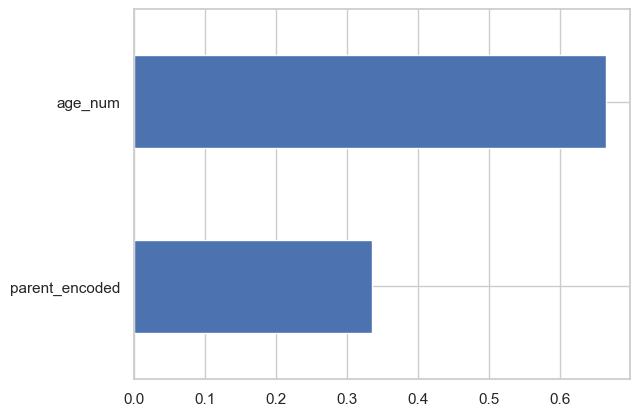

In [33]:
importance = pd.Series(
    rf.feature_importances_,
    index=X.columns
)

importance.sort_values().plot(kind="barh")

## Evaluation

In [34]:
print("Decision Tree accuracy:", accuracy_score(y_test, pred_tree))
print("Random Forest accuracy:", accuracy_score(y_test, pred_rf))

print("\nClassification report (Random Forest):")
print(classification_report(y_test, pred_rf))

Decision Tree accuracy: 0.38333333333333336
Random Forest accuracy: 0.325

Classification report (Random Forest):
              precision    recall  f1-score   support

           0       0.40      0.68      0.51        57
           1       0.00      0.00      0.00        24
           2       0.00      0.00      0.00        17
           3       0.00      0.00      0.00        22

    accuracy                           0.33       120
   macro avg       0.10      0.17      0.13       120
weighted avg       0.19      0.33      0.24       120



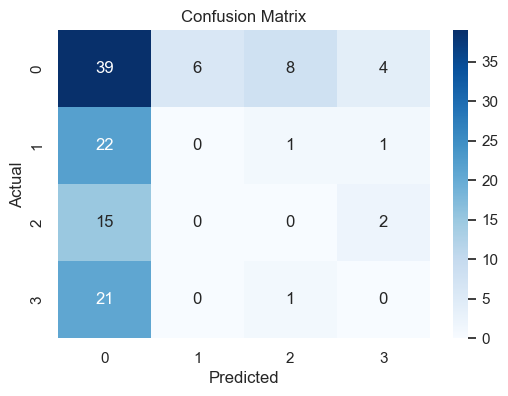

In [35]:
cm = confusion_matrix(y_test, pred_rf)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

Although the chi-square test indicates a statistically significant relationship between parental education and youth educational attainment, the predictive performance of the machine learning models remains limited.

This is likely because the dataset contains aggregated counts rather than individual-level observations and includes only a small number of explanatory variables.

### Linear Analysis

A linear regression model was used to examine whether parental education can predict youth education outcomes.

The model shows very low explanatory power (R² ≈ 0), indicating that parental education alone is not sufficient to accurately predict the educational level of young individuals.

This suggests that while social inheritance may exist, other factors such as environment, motivation, and socio-economic conditions also play an important role.

## Clustering

In [38]:
df_cluster = df[['total_2020_2024', 'education_score']].dropna().copy()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(scaled_features)

df.loc[df_cluster.index, 'cluster'] = df_cluster['cluster']

C:\Users\elmir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


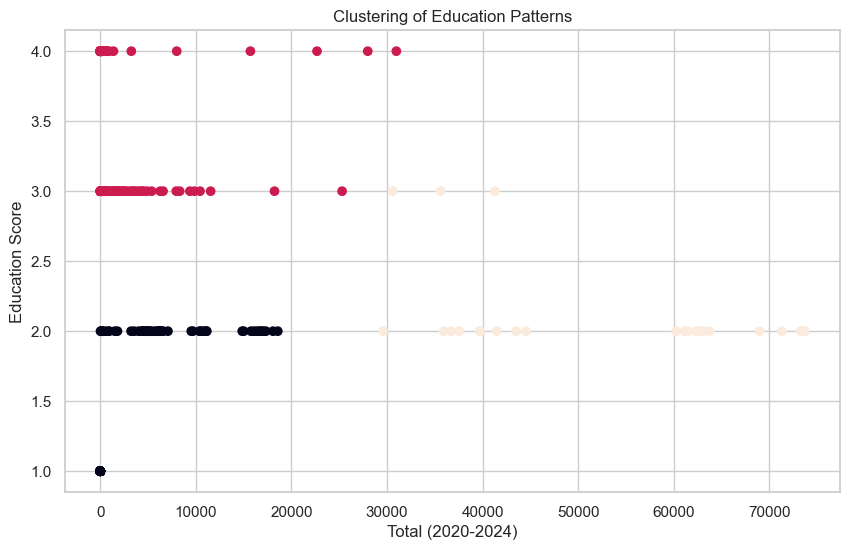

In [39]:
plt.figure(figsize=(10,6))

plt.scatter(
    df_cluster['total_2020_2024'],
    df_cluster['education_score'],
    c=df_cluster['cluster']
)

plt.xlabel("Total (2020-2024)")
plt.ylabel("Education Score")
plt.title("Clustering of Education Patterns")

plt.show()

## Clustering analysis

K-means clustering was used to identify patterns in education outcomes.
The results show three distinct clusters primarily separated by education level and population size.
Higher education levels (scores 3–4) form one cluster, while lower levels (score 2) are split into two clusters depending on population size.
This indicates that both education level and group size influence the clustering structure.
However, since education_score is a categorical variable, the clustering is limited in its ability to capture more nuanced differences.

Two groups may have the same education level but belong to different clusters due to differences in population size.

## improved Clustering model

C:\Users\elmir\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


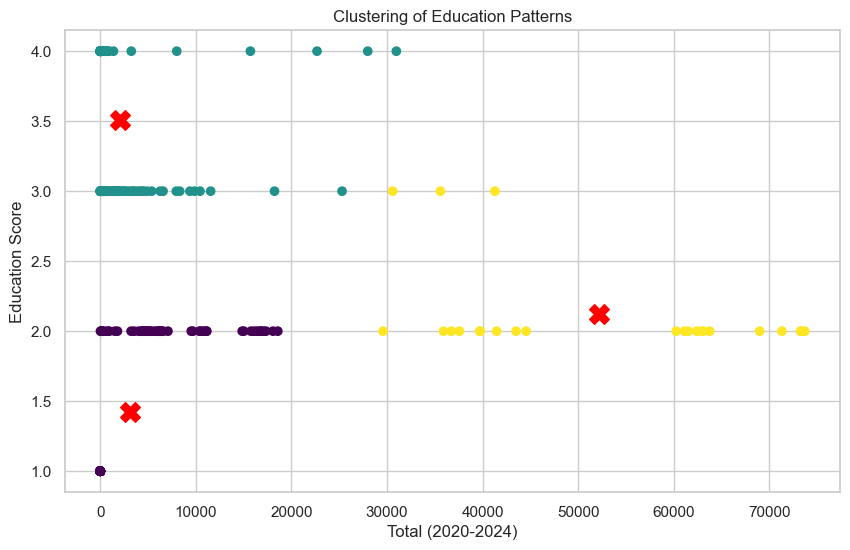

In [42]:
# 1. Clean data (fjern NaN)
df_cluster = df[['total_2020_2024', 'education_score']].dropna().copy()

# 2. Scale data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df_cluster)

# 3. Train KMeans
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(scaled_features)

# 4. (valgfrit) gem cluster i original df
df.loc[df_cluster.index, 'cluster'] = df_cluster['cluster']

# 5. Plot clusters
plt.figure(figsize=(10,6))

plt.scatter(
    df_cluster['total_2020_2024'],
    df_cluster['education_score'],
    c=df_cluster['cluster'],
    cmap='viridis'
)

# 6. Plot cluster centres (pro feature)
centers = scaler.inverse_transform(kmeans.cluster_centers_)
plt.scatter(centers[:,0], centers[:,1], c='red', s=200, marker='X')

plt.xlabel("Total (2020-2024)")
plt.ylabel("Education Score")
plt.title("Clustering of Education Patterns")

plt.show()

The clustering results reveal three distinct groups based on education level and population size.
One cluster represents individuals with higher education levels (scores 3–4), while another represents lower education levels (scores 1–2) in smaller populations.
The third cluster contains larger populations with medium education levels.
This indicates that both education level and group size play an important role in the structure of the data.

# Summary

Overall, the analysis shows a clear relationship between parental education, age, and youth educational attainment, although this relationship is complex and not easily predictable.

The statistical tests (chi-square and Spearman correlation) consistently indicate strong and significant associations. The chi-square tests confirm that educational attainment varies across both parental education groups and age groups, supporting the hypotheses. The Spearman correlation further shows a strong positive relationship between age and education level, suggesting that higher education becomes more common as individuals grow older.

The clustering analysis complements these findings by revealing three distinct groups based on both education level and population size. This demonstrates that educational patterns are not only influenced by attainment level but also by how individuals are distributed across groups. In particular, similar education levels can belong to different clusters depending on population size.

However, despite the strong statistical relationships, the machine learning models (Decision Tree and Random Forest) show low predictive performance. This indicates that parental education alone is not sufficient to accurately predict individual educational outcomes. A likely explanation is that the dataset consists of aggregated data and includes only a limited number of explanatory variables, which reduces the model’s ability to capture complex patterns.

In conclusion, the results suggest that social inheritance plays a role in educational attainment, but it is only one of several influencing factors. Other elements such as individual motivation, socio-economic conditions, and external environment are likely important for explaining educational outcomes.

Future analysis with individual-level data and additional variables could improve predictive performance and provide deeper insights.

In [ ]:
import os

# create data folder if it does not exist
os.makedirs("data", exist_ok=True)

# Save cleaned dataset (used for dashboard)
df.to_csv("data/Parent-education_clean.xlsx", index=False)

# Save machine learning dataset (if you created df_ml)
try:
    df_ml.to_csv("data/education_ml.csv", index=False)
except:
    print("No ML dataframe found (df_ml)")

print("Datasets saved successfully")

print("Clean dataset shape:", df.shape)

try:
    print("ML dataset shape:", df_ml.shape)
except:
    pass